### Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder, TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import TransformedTargetRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option('display.float_format', lambda x: '%.2f' % x)
sns.set_theme(style="whitegrid")

### Chargement & Split Stratifié

{
    "random_forest": {
        "name": "Random Forest",
        "artifact_name": "random_forest_model.joblib",
        "metrics": {
            "rmse": 121926.78,
            "mae": 64464.0,
            "r2": 0.942,
            "mape_percent": 12.72
        },
        "parameters": {
            "bootstrap": true,
            "ccp_alpha": 0.0,
            "criterion": "squared_error",
            "max_depth": 20,
            "max_features": 1.0,
            "max_leaf_nodes": null,
            "max_samples": null,
            "min_impurity_decrease": 0.0,
            "min_samples_leaf": 1,
            "min_samples_split": 2,
            "min_weight_fraction_leaf": 0.0,
            "monotonic_cst": null,
            "n_estimators": 100,
            "n_jobs": -1,
            "oob_score": false,
            "random_state": 42,
            "verbose": 0,
            "warm_start": false
        }
    },
    "svr": {
        "name": "SVR (Support Vector)",
        "artifact_name": "svr_model.joblib",
        "metrics": {
            "rmse": 168170.46,
            "mae": 91283.97,
            "r2": 0.8897,
            "mape_percent": 17.1
        },
        "parameters": {
            "C": 10,
            "cache_size": 200,
            "coef0": 0.0,
            "degree": 3,
            "epsilon": 0.1,
            "gamma": "scale",
            "kernel": "rbf",
            "max_iter": -1,
            "shrinking": true,
            "tol": 0.001,
            "verbose": false
        }
    },
    "linear_regression": {
        "name": "Linear Regression",
        "artifact_name": "linear_regression_model.joblib",
        "metrics": {
            "rmse": 221046.34,
            "mae": 109576.69,
            "r2": 0.8094,
            "mape_percent": 19.1
        },
        "parameters": {
            "copy_X": true,
            "fit_intercept": true,
            "n_jobs": null,
            "positive": false,
            "tol": 1e-06
        }
    }
}

In [2]:
df = pd.read_csv('../backend/data/houses_madrid_final_preprocessed.csv')

# stratification
df['price_bins'] = pd.qcut(df['buy_price'], q=10, labels=False)

X = df.drop(columns=['buy_price', 'price_bins'])
y = df['buy_price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=df['price_bins']
)

print("Chargé")
print(f"Train : {X_train.shape[0]} lignes | Test : {X_test.shape[0]} lignes")

Chargé
Train : 16334 lignes | Test : 4084 lignes


###  Le Pipeline de Preprocessing

In [3]:
# definition des features
# Numériques (On applique RobustScaler pour gérer les outliers)
numeric_features = ['sq_mt_built', 'n_rooms', 'n_bathrooms', 'floor', 'built_year', 'neigh_price_m2', 'energy_certificate']

# bouleen
bool_features = ['has_lift', 'has_parking', 'has_terrace', 'has_storage_room', 'has_pool', 'is_new_development']

# Catégorielles Haute Cardinalité (Quartiers -> Target Encoding)
high_card_features = ['neighborhood']

# Catégorielles Faible Cardinalité (District, Type -> OneHot Encoding)
low_card_features = ['district', 'house_type']

# transformes
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

target_enc_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('target_enc', TargetEncoder(target_type='continuous', smooth=10.0))
])

onehot_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('bool', 'passthrough', bool_features),
        ('high_card', target_enc_transformer, high_card_features),
        ('low_card', onehot_transformer, low_card_features)
    ],
    verbose_feature_names_out=False
)

###   Entraînement du Modèle

In [4]:
# pipeline
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, max_depth=20, random_state=42, n_jobs=-1))
])

# Ajout de la transformation Logarithmique sur la Cible (Prix)
# Cela aide le modèle à mieux prédire les variations de pourcentage plutôt que les valeurs absolues
final_model = TransformedTargetRegressor(
    regressor=model_pipeline,
    func=np.log1p,       # Avant entraînement : log(1 + prix)
    inverse_func=np.expm1 # Après prédiction : exp(pred) - 1
)

final_model.fit(X_train, y_train)
print("Entrainement terminé")

Entrainement terminé


### Évaluation

In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
import time

# 3 modèles 
models = {
    "Linear Regression": LinearRegression(),
    
    "Random Forest": RandomForestRegressor(
        n_estimators=100, 
        max_depth=20, 
        n_jobs=-1, 
        random_state=42
    ),
    
    "SVR (Support Vector)": SVR(
        kernel='rbf',    # Noyau Radial (standard)
        C=10,            # Pénalité (10 est souvent mieux que 1 pour l'immo)
        epsilon=0.1      # Marge d'erreur tolérée
    )
}

results = []

print(f"Lancement du Benchmark sur {len(models)} modèles...\n")

for name, model in models.items():
    start_time = time.time()
    print(f"Entraînement de : {name}...", end=" ")
    
    # Création du Pipeline pour ce modèle spécifique
    full_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])
    
    # Wrapper Log-Transformation (Crucial pour les 3 modèles)
    ttr_model = TransformedTargetRegressor(
        regressor=full_pipeline,
        func=np.log1p,
        inverse_func=np.expm1
    )
    
    # Entraînement
    ttr_model.fit(X_train, y_train)
    
    # Prédictions
    y_pred = ttr_model.predict(X_test)
    
    # Calcul des métriques
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    duration = time.time() - start_time
    
    # Stockage
    results.append({
        "Modèle": name,
        "MAPE (%)": mape,
        "RMSE (€)": rmse,
        "R2 Score": r2,
        "Temps (s)": duration,
        "Model_Object": ttr_model # On garde l'objet pour l'utiliser plus tard
    })
    
    print(f"(MAPE: {mape:.2f}%) en {duration:.1f}s")

# Conversion en DataFrame pour affichage
df_results = pd.DataFrame(results).set_index("Modèle").sort_values(by="MAPE (%)")

Lancement du Benchmark sur 3 modèles...

Entraînement de : Linear Regression... (MAPE: 19.10%) en 0.1s
Entraînement de : Random Forest... (MAPE: 12.72%) en 1.0s
Entraînement de : SVR (Support Vector)... (MAPE: 17.10%) en 5.7s


# 5. Recherche des meilleurs modèles (GridSearch)

In [6]:
print("-" * 50)
print("🏆 CLASSEMENT FINAL DES MODÈLES")
print("-" * 50)
print(df_results[["MAPE (%)", "RMSE (€)", "R2 Score", "Temps (s)"]])

# Sélection automatique du meilleur modèle (celui avec le MAPE le plus bas)
best_model_name = df_results.index[0]
best_model = df_results.iloc[0]["Model_Object"]
best_mape = df_results.iloc[0]["MAPE (%)"]

print(f"\n✅ LE VAINQUEUR EST : {best_model_name}")
print(f"Performance : {best_mape:.2f}% d'erreur moyenne.")

if best_mape < 10:
    print("Ce modèle est prêt pour la production (Excellent).")
elif best_mape < 15:
    print("Ce modèle est solide mais peut être optimisé (Acceptable).")
else:
    print("Attention : Performances insuffisantes. Vérifier les outliers.")

# Exemple de prédiction concrète avec le gagnant
sample = X_test.iloc[0:5]
predictions = best_model.predict(sample)
real_values = y_test.iloc[0:5].values

print("\n--- Test visuel sur 5 biens ---")
for i in range(5):
    err = abs(predictions[i] - real_values[i]) / real_values[i] * 100
    print(f"Réel : {real_values[i]:,.0f} € | Prédit : {predictions[i]:,.0f} € | Écart : {err:.1f}%")

--------------------------------------------------
🏆 CLASSEMENT FINAL DES MODÈLES
--------------------------------------------------
                      MAPE (%)  RMSE (€)  R2 Score  Temps (s)
Modèle                                                       
Random Forest            12.72 121926.78      0.94       1.02
SVR (Support Vector)     17.10 168170.46      0.89       5.68
Linear Regression        19.10 221046.34      0.81       0.05

✅ LE VAINQUEUR EST : Random Forest
Performance : 12.72% d'erreur moyenne.
Ce modèle est solide mais peut être optimisé (Acceptable).

--- Test visuel sur 5 biens ---
Réel : 997,000 € | Prédit : 727,805 € | Écart : 27.0%
Réel : 324,000 € | Prédit : 300,485 € | Écart : 7.3%
Réel : 799,000 € | Prédit : 843,086 € | Écart : 5.5%
Réel : 485,000 € | Prédit : 279,336 € | Écart : 42.4%
Réel : 1,500,000 € | Prédit : 1,492,908 € | Écart : 0.5%


# 6. Évaluation et Choix du "Champion"

In [7]:
# On prend un échantillon de 10 appartements au hasard dans le Test Set
sample_indices = X_test.sample(10, random_state=42).index
X_sample = X_test.loc[sample_indices]
y_sample = y_test.loc[sample_indices]

# On prépare le tableau comparatif
comparison_data = {
    'Prix Réel (€)': y_sample.values
}

# Pour chaque modèle entraîné, on prédit sur cet échantillon
for model_name, row in df_results.iterrows():
    model = row['Model_Object']
    preds = model.predict(X_sample)
    comparison_data[f'Pred {model_name}'] = preds

# Création du DataFrame
df_compare = pd.DataFrame(comparison_data)

# Ajout des écarts (Différence avec le réel) pour le Meilleur Modèle
winner_name = df_results.index[0]
df_compare['Écart Gagnant (€)'] = df_compare[f'Pred {winner_name}'] - df_compare['Prix Réel (€)']
df_compare['% Erreur'] = (df_compare['Écart Gagnant (€)'].abs() / df_compare['Prix Réel (€)'] * 100).round(1)

# Affichage propre
print(f"--- Comparatif sur 10 biens (Gagnant actuel : {winner_name}) ---")
display(df_compare.style.format("{:,.0f}", subset=df_compare.columns.drop('% Erreur')).background_gradient(cmap='Reds', subset=['% Erreur']))

--- Comparatif sur 10 biens (Gagnant actuel : Random Forest) ---


,Prix Réel (€),Pred Random Forest,Pred SVR (Support Vector),Pred Linear Regression,Écart Gagnant (€),% Erreur
0,"115,000","118,445","133,724","138,485","3,445",3.000000
1,"1,343,500","1,313,318","1,358,718","1,567,685","-30,182",2.200000
2,"269,000","265,571","268,795","292,174","-3,429",1.300000
3,"900,000","927,083","892,322","912,059","27,083",3.000000
4,"1,590,000","1,816,881","1,599,651","1,998,814","226,881",14.300000
5,"549,000","517,955","467,967","461,977","-31,045",5.700000
6,"1,940,000","1,924,343","1,592,415","1,421,335","-15,657",0.800000
7,"165,000","144,690","139,480","138,639","-20,310",12.300000
8,"825,000","765,256","789,815","766,539","-59,744",7.200000
9,"243,000","244,855","254,930","241,755","1,855",0.800000


# 7. Entraînement Final & Sauvegarde

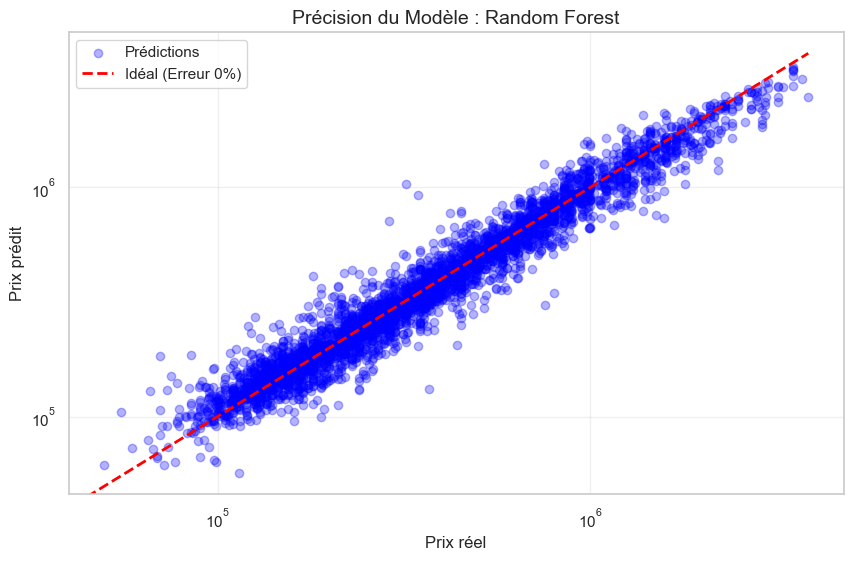

In [8]:
import matplotlib.pyplot as plt

# On récupère les prédictions du vainqueur sur tout le test set
best_model = df_results.iloc[0]["Model_Object"]
y_pred_final = best_model.predict(X_test)

plt.figure(figsize=(10, 6))

# Nuage de points
plt.scatter(y_test, y_pred_final, alpha=0.3, color='blue', label='Prédictions')

# Ligne parfaite (x=y)
max_val = max(y_test.max(), y_pred_final.max())
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', linewidth=2, label='Idéal (Erreur 0%)')

plt.title(f"Précision du Modèle : {df_results.index[0]}", fontsize=14)
plt.xlabel("Prix réel", fontsize=12)
plt.ylabel("Prix prédit", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

# Passage en échelle log pour mieux voir (car l'immobilier a de gros écarts)
plt.xscale('log')
plt.yscale('log')

plt.show()

### Sérialisation MLOps & Metadata Management

In [13]:
import json
import joblib
import os
from sklearn.metrics import mean_absolute_error

# Création du dossier de stockage
output_dir = "models_artifacts"
os.makedirs(output_dir, exist_ok=True)

metadata = {}

print(f" DÉMARRAGE DU PROCESSUS MLOPS (Output: {output_dir}/)...\n")

# On itère sur chaque modèle présent dans le tableau de résultats
for index, row in df_results.iterrows():
    # 1. Identification
    model_name_ui = row.name  # Ex: "Random Forest"
    model_object = row['Model_Object'] # L'objet TransformedTargetRegressor complet
    
    # Création de clés standardisées (snake_case)
    # Ex: "SVR (Support Vector)" -> "svr"
    safe_key = model_name_ui.lower().split('(')[0].strip().replace(' ', '_')
    artifact_filename = f"{safe_key}_model.joblib"
    artifact_path = os.path.join(output_dir, artifact_filename)
    
    # 2. Recalcul des métriques exactes pour le JSON (RMSE et R2 sont déjà dans df, mais on assure la MAE)
    # On refait une prédiction rapide pour garantir la cohérence des données exportées
    y_pred = model_object.predict(X_test)
    
    metrics = {
        "rmse": round(float(row['RMSE (€)']), 2),
        "mae": round(mean_absolute_error(y_test, y_pred), 2), # Calculé à la volée
        "r2": round(float(row['R2 Score']), 4),
        "mape_percent": round(float(row['MAPE (%)']), 2) # Ajout bonus utile
    }
    
    # 3. Extraction dynamique des hyperparamètres (Deep Introspection)
    # On va chercher les params du régresseur FINAL, caché derrière le TransformedTargetRegressor ET le Pipeline
    # Structure: TransformedTargetRegressor -> regressor_ (Pipeline) -> named_steps['regressor']
    try:
        final_estimator = model_object.regressor_.named_steps['regressor']
        params = final_estimator.get_params()
        
        # Filtrage optionnel : on peut retirer les params vides ou None pour alléger le JSON
        # params = {k: v for k, v in params.items() if v is not None}
    except Exception as e:
        print(f"⚠️ Impossible d'extraire les params pour {model_name_ui}: {e}")
        params = {}

    # 4. Sauvegarde de l'artéfact binaire (.joblib)
    joblib.dump(model_object, artifact_path, compress=('zlib', 3))
    # 5. Construction du dictionnaire de métadonnées
    metadata[safe_key] = {
        "name": model_name_ui,
        "artifact_name": artifact_filename,
        "metrics": metrics,
        "parameters": params
    }
    
    print(f"Modèle sauvegardé : {artifact_filename}")

# 6. Exportation du fichier JSON Master
json_path = os.path.join(output_dir, "models_metadata.json")
with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=4, ensure_ascii=False)

print(f"\n📝 Fichier de métadonnées généré : {json_path}")

 DÉMARRAGE DU PROCESSUS MLOPS (Output: models_artifacts/)...

Modèle sauvegardé : random_forest_model.joblib
Modèle sauvegardé : svr_model.joblib
Modèle sauvegardé : linear_regression_model.joblib

📝 Fichier de métadonnées généré : models_artifacts/models_metadata.json
